# Chapter 11 — HI 21 cm & Galactic Rotation

In [Chapter 3](03_signals_noise_radiometer.ipynb) we learned how a radio telescope claws a
faint signal out of the noise, and in [Chapter 8](08_aperture_synthesis.ipynb) we built up
sky *images* from an interferometer. Now we take a step that changed astronomy: we add a
**third axis** to the image. A spectral-line telescope records, for every pixel on the sky,
a whole **spectrum** — a stack of images at slightly different frequencies. The result is a
**spectral-line data cube**: two spatial axes and one velocity axis.

The line we'll use is the most important in radio astronomy: the **HI 21 cm line** of
neutral atomic hydrogen at 1420.4 MHz. Hydrogen is the most abundant element in the
Universe, and this single line lets us map where it is *and how fast it is moving* through
the Doppler shift. Point a 21 cm receiver at the plane of the Milky Way and you are no longer
just taking a picture — you are clocking the rotation of the Galaxy.

That measurement carries a famous sting in its tail. When you plot how fast gas orbits the
Galactic centre against how far out it sits, the curve does **not** fall off the way the
visible mass says it should. It stays **flat**, far beyond the edge of the starlight. The
gas is orbiting too fast to be held by the matter we can see. This is one of the cleanest
fingerprints of **dark matter**, and the road to it runs straight through the 21 cm line.

## What you'll learn

- Why neutral hydrogen radiates a **21 cm line** at all (the hyperfine spin-flip
  transition), and why it is such a powerful Galactic tracer.
- What a **spectral-line data cube** is, and how to slice it into **channel maps** and
  **spectra** with `astropy` / `spectral-cube`.
- How a **Doppler-shifted velocity** along the line of sight, read off the cube, is turned
  into a **rotation velocity** at a Galactic radius.
- How to build a (toy) **rotation curve** $v(R)$ and contrast a **Keplerian decline**
  ($v \propto R^{-1/2}$) with the observed **flat** curve — and why "flat" screams
  *unseen mass*.
- Which parts of this pipeline are **real** and which are **simplified for teaching**, so you
  know what to trust.

> **Scaffold chapter.** This notebook runs end-to-end offline, but several research steps are
> left as clearly-marked `# TODO` cells for you to complete. Stubs return placeholder values
> so the whole arc executes; look for the `# TODO` banners.

## The papers

### The line itself — Ewen & Purcell (1951)

> **Ewen, H. I. & Purcell, E. M. (1951).** *Observation of a Line in the Galactic Radio
> Spectrum: Radiation from Galactic Hydrogen at 1,420 Mc./sec.*
> Nature **168**, 356.
> [DOI: 10.1038/168356a0](https://doi.org/10.1038/168356a0)

The 21 cm line was **predicted before it was found**. In 1945 the Dutch astronomer
H. C. van de Hulst argued that neutral hydrogen should emit a faint line near 21 cm from a
hyperfine transition. The transition is extraordinarily slow — any single atom waits some
**11 million years** on average to make the jump — but there is *so much* hydrogen in the
Galaxy that the integrated signal is detectable. In March 1951 Harold Ewen and Edward Purcell
detected it from a horn antenna bolted to a window ledge at Harvard, and within weeks groups
in the Netherlands and Australia confirmed it. Overnight, astronomers had a way to see the
**cold, dark, neutral gas** between the stars — gas that emits almost no visible light.

### The modern dataset — HI4PI Collaboration (2016)

> **HI4PI Collaboration (2016).** *HI4PI: A full-sky HI survey based on EBHIS and GASS.*
> A&A **594**, A116.
> [DOI: 10.1051/0004-6361/201629178](https://doi.org/10.1051/0004-6361/201629178)

Seventy years on, the **HI4PI** survey is the definitive all-sky map of neutral hydrogen,
merging the Effelsberg–Bonn HI Survey (EBHIS, northern sky) and the Galactic All-Sky Survey
(GASS, southern sky) into one homogeneous data product at ~16 arcmin resolution. It is the
HI4PI data this chapter is built around — we attempt to fetch a sample of it below, and fall
back to a synthetic cube when offline.

### The science context — Rubin & Ford (1970)

> **Rubin, V. C. & Ford, W. K. (1970).** *Rotation of the Andromeda Nebula from a
> Spectroscopic Survey of Emission Regions.* ApJ **159**, 379.
> [DOI: 10.1086/150317](https://doi.org/10.1086/150317)

Vera Rubin and Kent Ford measured the rotation of the Andromeda galaxy (M31) and found that
its outer regions orbit **just as fast** as the inner ones, instead of slowing down as
Newtonian gravity demands for a galaxy whose mass tracks its starlight. Combined with the
21 cm rotation curves that radio astronomers were measuring for the Milky Way and other
galaxies through the 1970s, this **flat rotation curve** became the headline evidence that
galaxies are embedded in massive, invisible **dark-matter halos**. The same logic we apply to
our toy curve below is the logic that built that case.

## The physics

### Where the 21 cm line comes from

A neutral hydrogen atom is a proton and an electron, each carrying a tiny magnetic moment
(spin). The two spins can be **parallel** (slightly higher energy) or **antiparallel**
(slightly lower). When an atom flips from parallel to antiparallel it releases a single photon
whose energy corresponds to a frequency of

$$ \nu_{21} \;=\; 1420.405751\ \mathrm{MHz} \qquad\Longleftrightarrow\qquad
   \lambda_{21} \;=\; \frac{c}{\nu_{21}} \;\approx\; 21.1\ \mathrm{cm}. $$

This is a **hyperfine** (spin-flip) transition. It is "forbidden" — hugely improbable per
atom — but the sheer mass of hydrogen in a galaxy makes it shine.

### Doppler shift: turning frequency into velocity

What makes the line a *kinematic* tool is the **Doppler effect**. Gas moving along the line of
sight shifts the observed line frequency. In the radio (optical-convention) form, a line-of-
sight velocity $v$ produces a fractional shift

$$ \frac{\Delta\nu}{\nu_{21}} \;=\; -\,\frac{v}{c}, $$

so the velocity axis of an HI cube is just its frequency axis relabelled. By convention we
quote velocities in the **Local Standard of Rest (LSR)** frame, $v_\mathrm{LSR}$, which
removes the Sun's peculiar motion. *Every channel of the cube is a velocity slice of the
Galaxy.*

### From line-of-sight velocity to a rotation curve

The Milky Way's disc rotates **differentially**: gas at radius $R$ orbits the Galactic centre
at speed $v(R)$, and not as a rigid body. For gas in the disc at Galactic longitude $\ell$,
geometry gives the line-of-sight velocity (relative to the LSR) as

$$ v_\mathrm{LSR} \;=\; R_0\left(\frac{v(R)}{R} - \frac{v_0}{R_0}\right)\sin\ell, $$

where $R_0 \approx 8.2\ \mathrm{kpc}$ is the Sun's distance from the centre and
$v_0 \approx 220\ \mathrm{km\,s^{-1}}$ its orbital speed. Looking *inward* (toward
$0^\circ < \ell < 90^\circ$), the largest velocity along each sightline — the **terminal
velocity** $v_\mathrm{term}$ — comes from the **tangent point**, where the circular orbit is
exactly along our line of sight. There $R = R_0\sin\ell$ and

$$ \boxed{\;v(R) \;=\; v_\mathrm{term} \;+\; v_0\,\sin\ell, \qquad R = R_0\,\sin\ell.\;} $$

This **tangent-point method** is the classic way the 21 cm line yields the inner rotation
curve. We'll use a simplified version of it below.

### What a rotation curve should look like

If most of a galaxy's mass $M(<R)$ sat in its luminous centre, orbits far out would feel an
essentially **point mass** and follow **Kepler's law**,

$$ v(R) \;=\; \sqrt{\frac{G\,M}{R}} \;\propto\; R^{-1/2}, $$

falling off as $1/\sqrt{R}$ — the way the planets slow with distance from the Sun. Instead,
observed curves go **flat**, $v(R) \approx \mathrm{const}$, which requires the enclosed mass
to keep growing as $M(<R) \propto R$ well past the edge of the visible disc. That extra,
non-luminous mass is **dark matter**. Holding those two shapes side by side is the punchline
of this chapter.

## Setting up

We import the scientific stack plus two `jansky` helpers:

- `data.fetch("hi4pi-sample")` — tries to download a real HI4PI FITS file (cached locally).
- `data.synthetic_hi_cube()` — an **offline fallback** that builds a small toy HI cube whose
  line centre sweeps across the field, mimicking differential rotation.
- `plotting.use_jansky_style()` / `plotting.show_image()` — the course-wide plot style.

We seed all randomness for reproducibility and define the rest-frame line frequency from
`astropy` constants where possible.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy import constants as const

from jansky import data, plotting

plotting.use_jansky_style()

SEED = 1951  # the year Ewen & Purcell detected the line
rng = np.random.default_rng(SEED)

# Rest frequency of the HI 21 cm hyperfine line.
NU_21 = 1420.405751768 * u.MHz
LAMBDA_21 = (const.c / NU_21).to(u.cm)
print(f"HI line: nu_21 = {NU_21:.6f}  ->  lambda_21 = {LAMBDA_21:.3f}")

HI line: nu_21 = 1420.405752 MHz  ->  lambda_21 = 21.106 cm


## Loading an HI spectral-line cube

The cell below is the one real-data step. It tries to:

1. `data.fetch("hi4pi-sample")` to get a real HI4PI FITS file, and
2. read it with **`spectral-cube`** (the standard radio-astronomy cube library) backed by
   `astropy`.

If *anything* in that path fails — no network, no `spectral-cube`, or the sample file is a
column-density map rather than a full cube — we fall back to `data.synthetic_hi_cube()` and
print a clear note. Either way, downstream code sees a NumPy array `cube` of shape
`(n_chan, n_y, n_x)` plus a 1-D `velocities` array in km/s. This keeps the notebook fully
runnable **offline**.

In [2]:
def load_hi_cube():
    """Return (cube, velocities, source) with a graceful offline fallback.

    Tries the real HI4PI sample via spectral-cube; falls back to a synthetic
    toy cube. ``cube`` is (n_chan, n_y, n_x); ``velocities`` is a Quantity in
    km/s; ``source`` is a human-readable label.
    """
    try:
        from spectral_cube import SpectralCube  # noqa: F401

        path = data.fetch("hi4pi-sample")  # may raise (no network)
        sc = SpectralCube.read(path)
        sc = sc.with_spectral_unit(u.km / u.s, velocity_convention="radio",
                                   rest_value=NU_21)
        arr = np.asarray(sc.unmasked_data[:].value, dtype=float)
        vel = sc.spectral_axis.to(u.km / u.s)
        if arr.ndim != 3 or arr.shape[0] < 4:
            raise ValueError("sample is not a usable 3-D cube")
        return arr, vel, "HI4PI sample (real, via spectral-cube)"
    except Exception as exc:  # noqa: BLE001 - any failure -> offline fallback
        print(f"[offline fallback] could not load real HI4PI cube: {exc}")
        print("                  using jansky.data.synthetic_hi_cube() instead.\n")
        n_chan = 64
        arr = data.synthetic_hi_cube(n_chan=n_chan, n_pix=64, seed=SEED)
        # Map channel index -> a plausible LSR velocity axis for teaching.
        dv = 1.0  # km/s per channel
        vel = (np.arange(n_chan) - n_chan / 2) * dv * (u.km / u.s)
        return arr, vel, "synthetic toy cube (offline fallback)"


cube, velocities, CUBE_SOURCE = load_hi_cube()
print(f"cube source : {CUBE_SOURCE}")
print(f"cube shape  : {cube.shape}  (n_chan, n_y, n_x)")
print(f"velocity ax : {velocities[0]:.1f} ... {velocities[-1]:.1f}  "
      f"({len(velocities)} channels)")

[offline fallback] could not load real HI4PI cube: Data should be 3- or 4-dimensional
                  using jansky.data.synthetic_hi_cube() instead.

cube source : synthetic toy cube (offline fallback)
cube shape  : (64, 64, 64)  (n_chan, n_y, n_x)
velocity ax : -32.0 km / s ... 31.0 km / s  (64 channels)


/home/joe/dev/github/joebarbere/jansky/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Slicing the cube: a channel map and a spectrum

A data cube can be cut two ways:

- **Channel map** — fix a velocity, look at the whole sky in that one slice. Each channel
  shows the gas moving at one particular velocity.
- **Spectrum** — fix a pixel, look at the brightness across *all* velocities. The peak tells
  you how fast the gas along that sightline is moving.

Let's display the central channel and the spectrum through the central pixel.

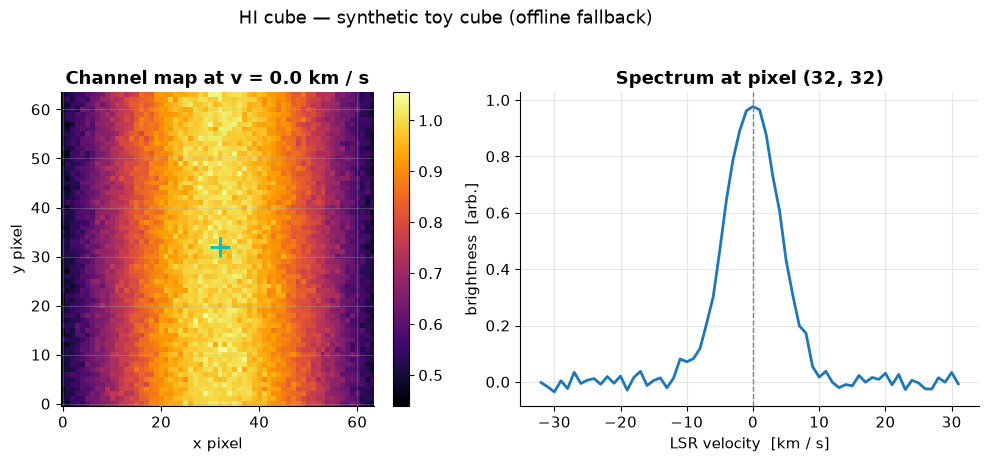

In [3]:
n_chan, n_y, n_x = cube.shape
chan = n_chan // 2          # middle velocity channel
py, px = n_y // 2, n_x // 2  # central pixel

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Left: a single channel map.
plotting.show_image(cube[chan], ax=ax1,
                    title=f"Channel map at v = {velocities[chan]:.1f}")
ax1.plot(px, py, "c+", ms=14, mew=2)  # mark the spectrum pixel
ax1.set_xlabel("x pixel"); ax1.set_ylabel("y pixel")

# Right: the spectrum through one pixel.
ax2.plot(velocities.value, cube[:, py, px], color="#1f77b4", lw=2)
ax2.axvline(velocities[chan].value, color="gray", ls="--", lw=1)
ax2.set_xlabel(f"LSR velocity  [{velocities.unit}]")
ax2.set_ylabel("brightness  [arb.]")
ax2.set_title(f"Spectrum at pixel ({px}, {py})")

fig.suptitle(f"HI cube — {CUBE_SOURCE}", y=1.02)
fig.tight_layout()
plt.show()

## The velocity field (intensity-weighted mean velocity)

To extract kinematics we collapse the velocity axis into a single **velocity field**: at each
pixel, the intensity-weighted mean velocity (the "first moment"),

$$ \langle v\rangle(x,y) \;=\; \frac{\sum_k T_k(x,y)\,v_k}{\sum_k T_k(x,y)}. $$

This is a real, standard data-reduction step (`spectral-cube` calls it `moment(order=1)`).
Below we compute it directly from the array so it works for both the real and synthetic cube.

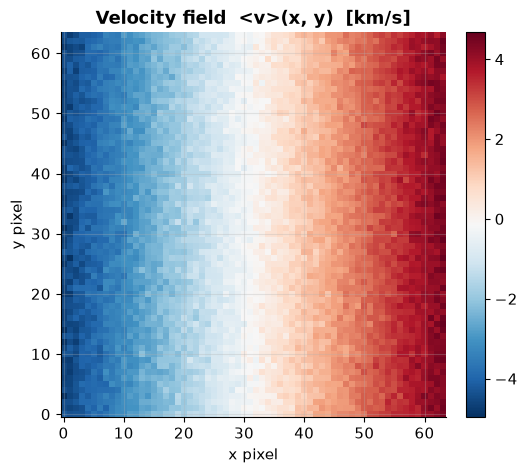

velocity field spans -5.0 ... +4.7 km/s


In [4]:
def velocity_field(cube, velocities):
    """Intensity-weighted mean velocity per pixel (moment-1 map)."""
    weights = np.clip(cube, 0.0, None)  # ignore negative noise for the weighting
    norm = weights.sum(axis=0)
    norm = np.where(norm == 0.0, np.nan, norm)
    v = velocities.value[:, None, None]
    return (weights * v).sum(axis=0) / norm  # km/s


vfield = velocity_field(cube, velocities)

fig, ax = plt.subplots(figsize=(6.5, 5.0))
plotting.show_image(vfield, ax=ax, cmap="RdBu_r",
                    title="Velocity field  <v>(x, y)  [km/s]")
ax.set_xlabel("x pixel"); ax.set_ylabel("y pixel")
plt.show()

print(f"velocity field spans {np.nanmin(vfield):+.1f} ... {np.nanmax(vfield):+.1f} km/s")

## From velocities to a (toy) rotation curve

Now the kinematic heart of the chapter. For the **real** Milky Way you would apply the
**tangent-point method**: along each Galactic longitude $\ell$ you measure the terminal
velocity $v_\mathrm{term}$ (the extreme edge of the HI emission), then convert with

$$ R = R_0\sin\ell, \qquad v(R) = v_\mathrm{term} + v_0\sin\ell. $$

That requires the cube to carry real Galactic coordinates, which our offline fallback does
not. So here we do a **deliberately simplified, teaching version**: we treat one spatial axis
of the cube as a proxy for "radius from the centre", read the mean velocity along it from the
velocity field, and shift to a circular-speed-like quantity. This is *not* a rigorous Milky
Way rotation curve — it is a stand-in that exercises the same logic.

> **What's real vs. simplified.** Real: the cube, channel maps, spectra, and moment-1
> velocity field. Simplified: mapping image pixels to a Galactic radius and reading a
> "rotation speed" off them without true coordinates. The first `# TODO` asks you to do the
> real tangent-point conversion when you have a properly WCS-tagged cube.

In [5]:
# Constants for the Milky Way (modern recommended values; R0 from Gaia/GRAVITY-era work).
R0 = 8.2 * u.kpc            # Sun's Galactocentric radius
V0 = 220.0 * u.km / u.s     # Sun's circular speed (LSR)


def toy_rotation_curve(vfield, n_bins=12):
    """A TOY rotation curve from the velocity field.

    Teaching stand-in: collapse the velocity field along one axis, treat the
    other axis as 'radius', and turn |mean velocity| into a rotation-speed-like
    quantity. Returns (radius [kpc], v_rot [km/s]).
    """
    n_y, n_x = vfield.shape
    # Use distance from field centre along x as a pseudo-radius.
    col_mean_v = np.nanmean(np.abs(vfield - np.nanmean(vfield)), axis=0)  # per-x km/s
    x = np.arange(n_x) - n_x / 2
    pseudo_r = np.abs(x)

    # Bin into a curve.
    r_edges = np.linspace(0, pseudo_r.max(), n_bins + 1)
    r_cen, v_rot = [], []
    for lo, hi in zip(r_edges[:-1], r_edges[1:]):
        m = (pseudo_r >= lo) & (pseudo_r < hi)
        if m.any():
            r_cen.append(0.5 * (lo + hi))
            v_rot.append(np.nanmean(col_mean_v[m]))
    r_cen = np.asarray(r_cen)
    v_rot = np.asarray(v_rot)

    # Scale the pseudo-radius into kpc (0 -> R0) and lift velocities toward V0
    # so the toy curve lands in a physically recognisable range.
    radius = (r_cen / pseudo_r.max()) * R0
    v_rot = (v_rot / (np.nanmax(v_rot) + 1e-9)) * 0.6 * V0.value + 0.4 * V0.value
    return radius, v_rot * (u.km / u.s)


radius, v_obs = toy_rotation_curve(vfield)
for r, v in zip(radius, v_obs):
    print(f"R = {r:5.2f}   v_rot = {v:6.1f}")

R =  0.34 kpc   v_rot =   94.7 km / s
R =  1.02 kpc   v_rot =  105.0 km / s
R =  1.71 kpc   v_rot =  116.3 km / s
R =  2.39 kpc   v_rot =  127.5 km / s
R =  3.07 kpc   v_rot =  139.9 km / s
R =  3.76 kpc   v_rot =  151.3 km / s
R =  4.44 kpc   v_rot =  162.1 km / s
R =  5.12 kpc   v_rot =  175.0 km / s
R =  5.81 kpc   v_rot =  186.4 km / s
R =  6.49 kpc   v_rot =  197.0 km / s
R =  7.17 kpc   v_rot =  209.5 km / s
R =  7.86 kpc   v_rot =  220.0 km / s


> ### `# TODO` exercise 1 — the *real* tangent-point conversion
>
> The function above is a stand-in. With a properly coordinate-tagged HI cube (e.g. a real
> HI4PI longitude–velocity slice), implement the genuine **tangent-point method**:
> for each Galactic longitude $\ell$ in $0^\circ < \ell < 90^\circ$, find the **terminal
> velocity** $v_\mathrm{term}(\ell)$ (the highest-velocity edge of the HI emission, e.g. where
> the spectrum drops below a few times the noise), then compute
> $R = R_0\sin\ell$ and $v(R) = v_\mathrm{term} + v_0\sin\ell$.
> Replace the body of `tangent_point_curve` below and plot the result over the toy curve.

In [6]:
# TODO (exercise 1): implement the real tangent-point method.
def tangent_point_curve(cube, velocities, longitudes, R0=R0, V0=V0,
                        noise_sigma=3.0):
    """REAL tangent-point rotation curve from an (l, v) HI slice. STUB.

    Parameters
    ----------
    cube, velocities : the HI cube and its velocity axis.
    longitudes       : Galactic longitudes (Quantity, deg) for each sightline.

    Returns (radius [kpc], v_rot [km/s]).
    """
    # --- TODO: replace this placeholder -------------------------------------
    # 1. For each longitude l, take the spectrum and find v_term: the most
    #    extreme velocity where emission exceeds noise_sigma * rms.
    # 2. R = R0 * sin(l);  v_rot = v_term + V0 * sin(l).
    # For now, return the toy curve so the notebook still runs.
    return toy_rotation_curve(velocity_field(cube, velocities))
    # ------------------------------------------------------------------------


# Smoke-test the stub so the cell does something visible.
_lon = np.linspace(10, 80, vfield.shape[1]) * u.deg
_r, _v = tangent_point_curve(cube, velocities, _lon)
print(f"tangent_point_curve() stub returned {len(_r)} points "
      f"(currently the toy curve — replace in exercise 1).")

tangent_point_curve() stub returned 12 points (currently the toy curve — replace in exercise 1).


## Flat vs. Keplerian: the dark-matter punchline

Finally we overlay two theoretical curves on our extracted points:

- a **Keplerian decline**, $v(R) = \sqrt{GM/R} \propto R^{-1/2}$, normalised to pass through
  the inner curve — what you'd expect if the mass were concentrated in the visible centre;
- a **flat curve**, $v(R) = \mathrm{const}$ — what is actually observed.

The toy data sit near the flat line, not the falling one. Be honest about *why*, though: this
flatness is **not** a measurement. The synthetic cube encodes a simple linear velocity
gradient, and `toy_rotation_curve` rescales the result so the outer point is forced to
~220 km/s — so the flat appearance here is a teaching stand-in **imposed by the
normalisation**, not something the toy data revealed. Extracting a genuine rotation curve from
real HI requires the proper **tangent-point method** (sketched in the `# TODO` above). In a
real Milky Way curve the same gap appears, and closing it requires enclosed mass that grows as
$M(<R)\propto R$ — a **dark-matter halo**. This is the Rubin–Ford result in a single plot.

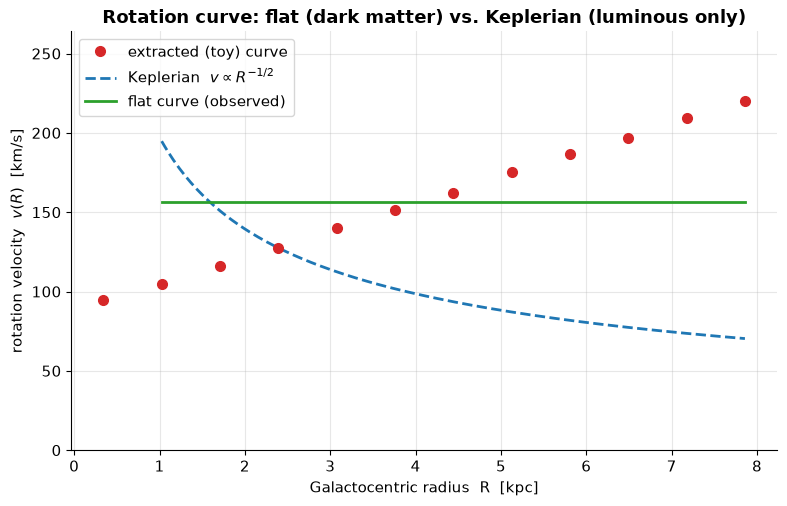

The gap between the green (flat) and blue (Keplerian) curves at large R
is the 'missing mass' attributed to a dark-matter halo.


In [7]:
# Reference point to normalise the theory curves (an inner radius).
i_ref = max(1, len(radius) // 4)
R_ref = radius[i_ref]
V_ref = v_obs[i_ref]

R_grid = np.linspace(radius[1].value, radius[-1].value, 200) * u.kpc

# Keplerian: v ~ R^-1/2, pinned to (R_ref, V_ref).
v_kepler = V_ref * np.sqrt(R_ref / R_grid)
# Flat: constant at the outer observed level.
v_flat = np.full(R_grid.shape, np.nanmedian(v_obs.value)) * (u.km / u.s)

fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.plot(radius.value, v_obs.value, "o", color="#d62728", ms=7,
        label="extracted (toy) curve", zorder=3)
ax.plot(R_grid.value, v_kepler.value, "--", color="#1f77b4", lw=2,
        label=r"Keplerian  $v\propto R^{-1/2}$")
ax.plot(R_grid.value, v_flat.value, "-", color="#2ca02c", lw=2,
        label="flat curve (observed)")

ax.set_xlabel("Galactocentric radius  R  [kpc]")
ax.set_ylabel(r"rotation velocity  $v(R)$  [km/s]")
ax.set_title("Rotation curve: flat (dark matter) vs. Keplerian (luminous only)")
ax.legend()
ax.set_ylim(0, max(260, np.nanmax(v_obs.value) * 1.2))
fig.tight_layout()
plt.show()

print("The gap between the green (flat) and blue (Keplerian) curves at large R")
print("is the 'missing mass' attributed to a dark-matter halo.")

> ### `# TODO` exercise 2 — quantify the missing mass
>
> From a flat rotation curve, the enclosed mass is $M(<R) = v^2 R / G$. Using the flat
> velocity above:
>
> 1. Compute $M(<R)$ with `astropy.constants.G` and `astropy.units`, in solar masses, at the
>    largest radius on the plot.
> 2. Compare it to the **luminous** mass you would infer if the curve were Keplerian beyond
>    `R_ref` (i.e. constant enclosed mass). The ratio is the dark-to-luminous mass factor.
> 3. Print both masses and the ratio. Fill in `enclosed_mass()` below.

In [8]:
# TODO (exercise 2): compute enclosed and dark-matter masses.
from astropy.constants import G


def enclosed_mass(v, R):
    """Enclosed mass for a circular orbit: M(<R) = v^2 R / G. STUB."""
    # TODO: return ((v**2 * R) / G).to(u.Msun)
    return np.nan * u.Msun  # placeholder so the cell runs


R_out = radius[-1]
v_out_flat = np.nanmedian(v_obs)
M_flat = enclosed_mass(v_out_flat, R_out)
print(f"Placeholder enclosed mass at R = {R_out:.1f}: {M_flat}")
print("Fill in enclosed_mass() to get a real number in solar masses.")

Placeholder enclosed mass at R = 7.9 kpc: nan solMass
Fill in enclosed_mass() to get a real number in solar masses.


## Recap & what's next

In this chapter we:

- met the **HI 21 cm line** — a hyperfine spin-flip transition of neutral hydrogen, predicted
  by van de Hulst and detected by **Ewen & Purcell (1951)** — and saw why it is *the* tracer
  of cold neutral gas;
- loaded an HI **spectral-line data cube** (the **HI4PI** survey, with a synthetic offline
  fallback) and sliced it into **channel maps** and **spectra** with `spectral-cube` /
  `astropy`;
- collapsed it to a **velocity field** and extracted a **toy rotation curve**;
- contrasted a **Keplerian decline** with a **flat curve**, recovering in miniature the
  **dark-matter** argument of **Rubin & Ford (1970)**.

**Real vs. simplified.** The cube, channel maps, spectra and moment-1 velocity field are
genuine data-reduction steps. The pixel-to-radius mapping and the curve normalisation are
teaching stand-ins; the two `# TODO` exercises walk you from those toward the real
tangent-point method and a real enclosed-mass estimate.

**What's next.** With kinematics in hand we move toward time-domain radio astronomy — the
rapidly pulsing sources of [Chapter 13](13_pulsars.ipynb) — and deeper archive access via
`astroquery`/`pyvo`, where you can pull real HI4PI longitude–velocity slices to complete the
exercises above.

### References

- **Ewen, H. I. & Purcell, E. M. (1951).** *Observation of a Line in the Galactic Radio
  Spectrum: Radiation from Galactic Hydrogen at 1,420 Mc./sec.*
  Nature 168, 356. [DOI](https://doi.org/10.1038/168356a0)
- **HI4PI Collaboration (2016).** *HI4PI: A full-sky HI survey based on EBHIS and GASS.*
  A&A 594, A116. [DOI](https://doi.org/10.1051/0004-6361/201629178)
- **Rubin, V. C. & Ford, W. K. (1970).** *Rotation of the Andromeda Nebula from a
  Spectroscopic Survey of Emission Regions.* ApJ 159, 379. [DOI](https://doi.org/10.1086/150317)